In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
list_AC_stark_vals=[np.float64(2.9871900648194566e-05), np.float64(0.00013669414394658285), np.float64(0.0002973837298951648), np.float64(0.0005219406584939405), np.float64(0.0008103649297429103), np.float64(0.001162656543642073), np.float64(0.0015188155001914301), np.float64(0.0019088417993909804), np.float64(0.0024227354412407255), np.float64(0.0029504964257406644), np.float64(0.0034521247528907957), np.float64(0.004117620422691119), np.float64(0.005426983435141641), np.float64(0.005430213790242355), np.float64(0.005587311487993258), np.float64(0.00599827652839436), np.float64(0.005413108911445657), np.float64(0.007381808637147144), np.float64(0.007404375705498828), np.float64(0.008700810116500705)]
list_AC_stark_vals=[np.float64(2.9871900648194566e-05), np.float64(0.00013669414394658285), np.float64(-0.0007026162701048353), np.float64(-0.0004780593415060595), np.float64(-0.0011896350702570897), np.float64(-0.0008373434563579271), np.float64(-0.00148118449980857), np.float64(-0.00209115820060902), np.float64(-0.0025772645587592746), np.float64(-0.004049503574259336), np.float64(-0.0035478752471092044), np.float64(-0.0048823795773088804), np.float64(-0.005573016564858358), np.float64(-0.0065697862097576455), np.float64(-0.0074126885120067414), np.float64(-0.00800172347160564), np.float64(-0.008586891088554344), np.float64(-0.009618191362852857), np.float64(-0.011595624294501172), np.float64(-0.011299189883499296)]

## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [6]:
def find_params(f_d,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    avg_e_vals=[]
    avg_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)
        
        if A < 0.13:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=10,drag=True,use_avg=True)
        elif A < 16:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=5,drag=True,use_avg=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=1,drag=True,use_avg=True)

        avg_e_vals.append(sim_vals[0])
        avg_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.semilogy(AC_stark_vals, avg_e_vals)
    plt.semilogy(AC_stark_vals, avg_f_vals)
    plt.legend(["e","f"])
    plt.xlabel("ω_supp-ω_ef (GHz)")
    plt.ylabel("Tason todennäköisyyden keskiarvo")
    plt.show()
    
    index=np.argmin(avg_f_vals)
    AC_stark=AC_stark_vals[index]
    e_max=avg_e_vals[index]
    f_max=avg_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],avg_e_vals)

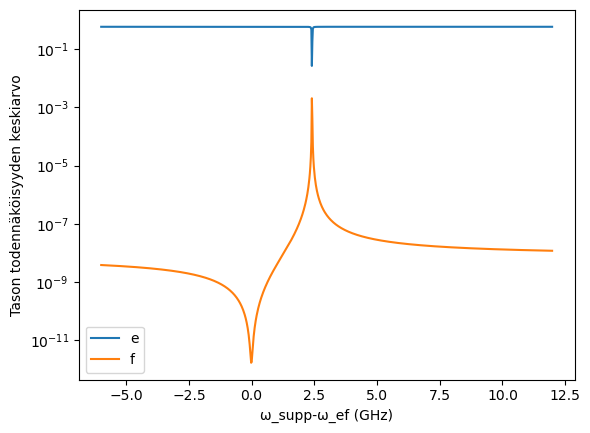

Amplitudi (GHz): 0.012744300694748212
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9999754574461227
Pulssin pituus (ns): 251.57913925969248
Rabi-taajuus (fourier):  0.0020283208289489786


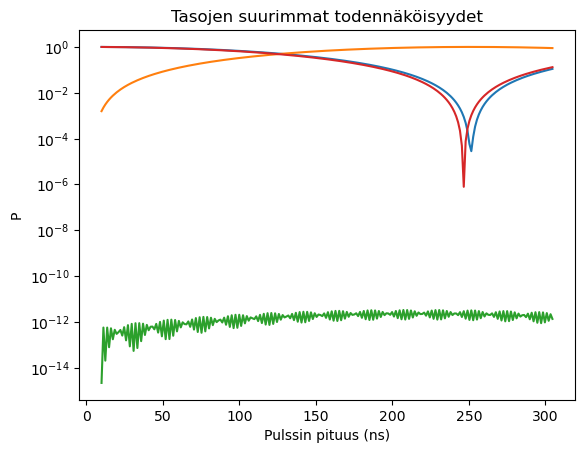

---------------------------------------------


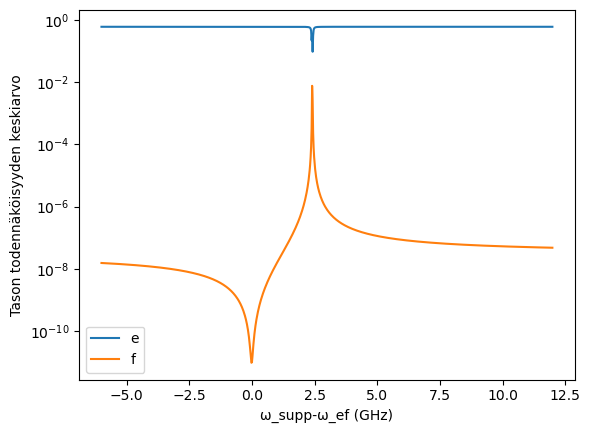

Amplitudi (GHz): 0.025488601389496424
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9998881960536458
Pulssin pituus (ns): 128.32398047912534
Rabi-taajuus (fourier):  0.0040566586591860125


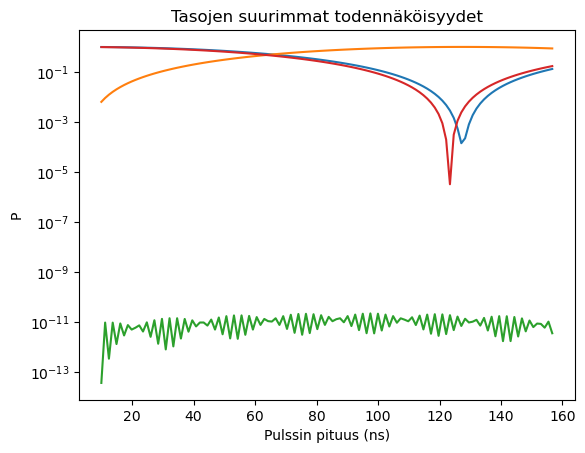

---------------------------------------------


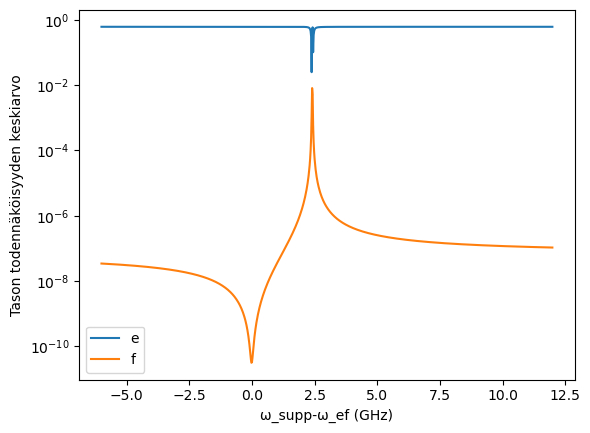

Amplitudi (GHz): 0.03823290208424464
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9998836561651651
Pulssin pituus (ns): 86.42008713843916
Rabi-taajuus (fourier):  0.006092403122079832


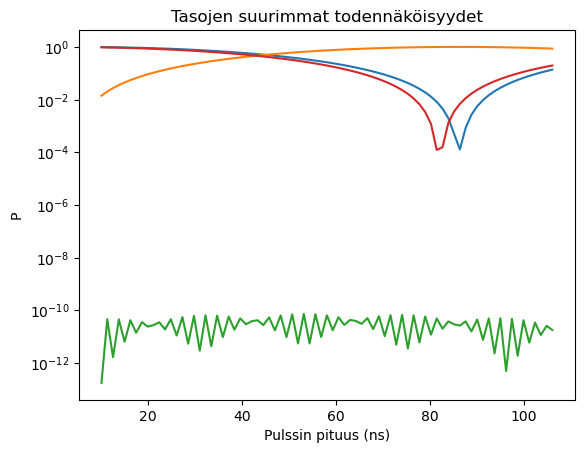

---------------------------------------------


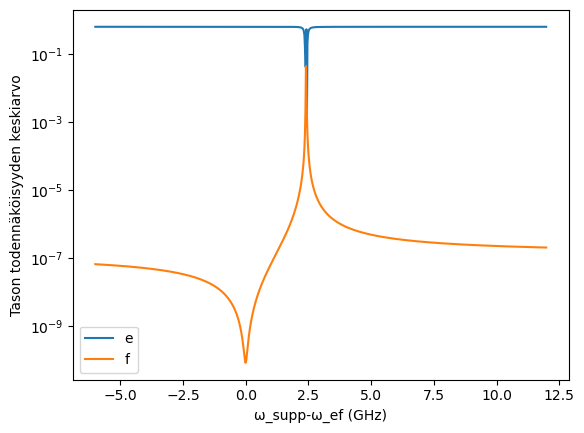

Amplitudi (GHz): 0.05097720277899285
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999934650452958
Pulssin pituus (ns): 66.69827479772013
Rabi-taajuus (fourier):  0.008126666079726248


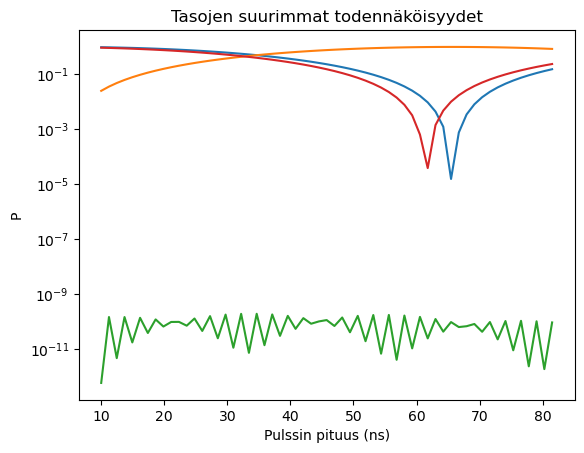

---------------------------------------------


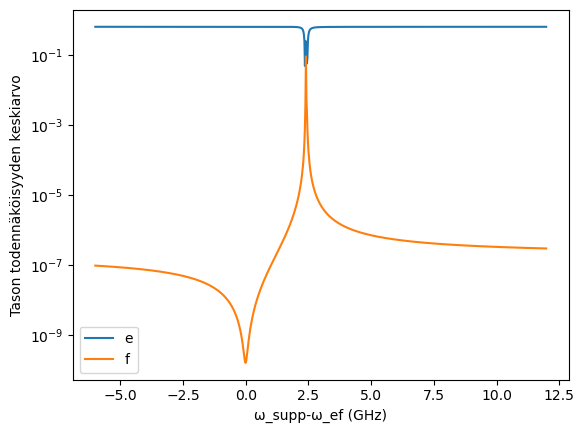

Amplitudi (GHz): 0.06372150347374106
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999662126031618
Pulssin pituus (ns): 54.37380171001159
Rabi-taajuus (fourier):  0.010162290356581387


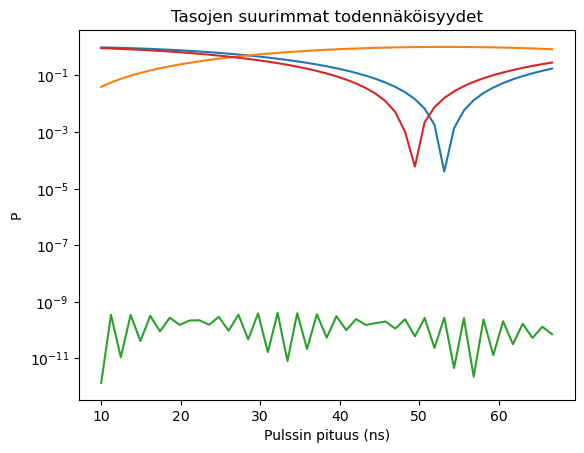

---------------------------------------------


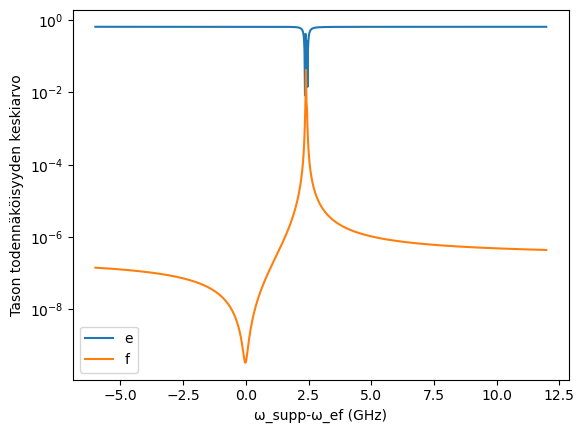

Amplitudi (GHz): 0.07646580416848928
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9999750422841611
Pulssin pituus (ns): 44.51247984782758
Rabi-taajuus (fourier):  0.012200010936201995


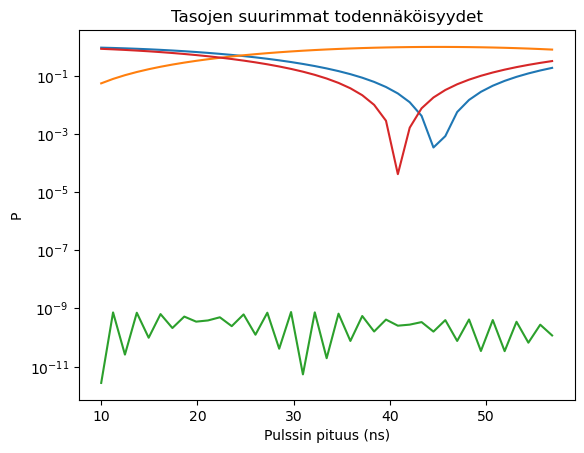

---------------------------------------------


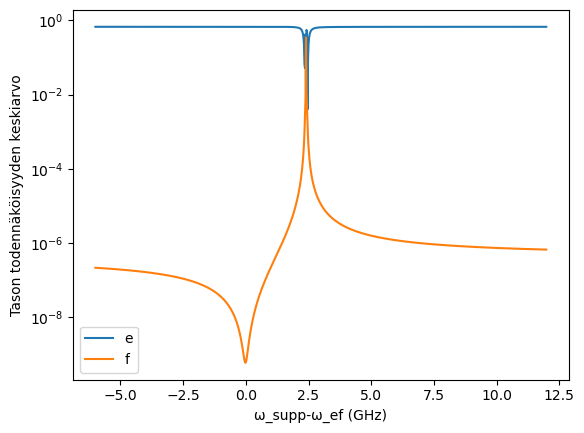

Amplitudi (GHz): 0.08921010486323748
AC-stark siirtymä (GHz): -0.02
E-tason suurin todennäköisyys: 0.9999940639264325
Pulssin pituus (ns): 39.58287287057783
Rabi-taajuus (fourier):  0.014232986546675541


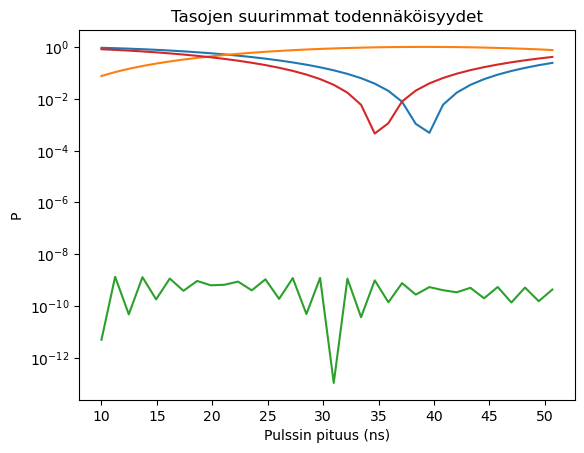

---------------------------------------------


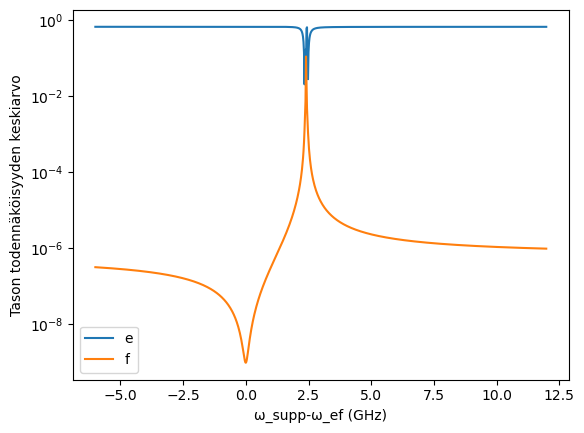

Amplitudi (GHz): 0.1019544055579857
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999996829282374
Pulssin pituus (ns): 34.65298406944798
Rabi-taajuus (fourier):  0.01627948127948988


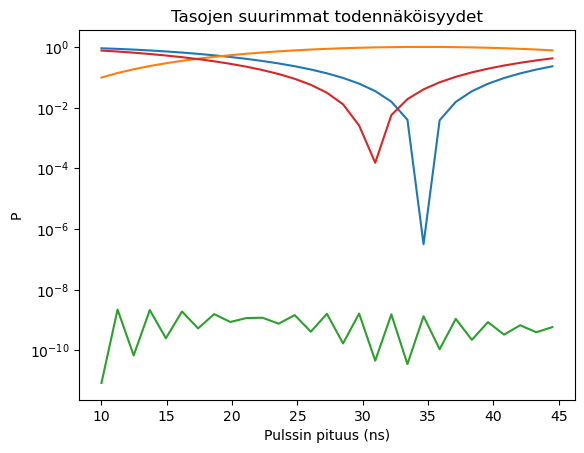

---------------------------------------------


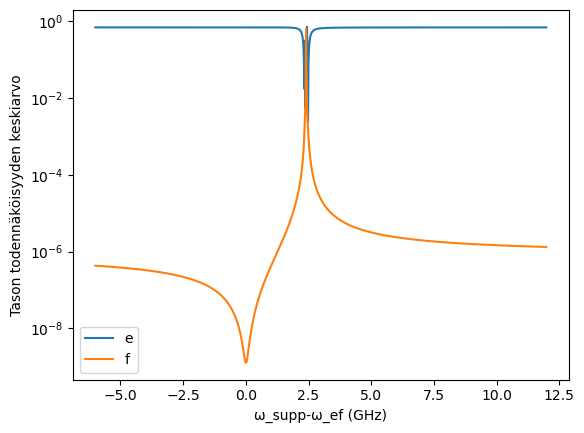

Amplitudi (GHz): 0.11469870625273391
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999972875014858
Pulssin pituus (ns): 32.18810885817389
Rabi-taajuus (fourier):  0.01829876715448028


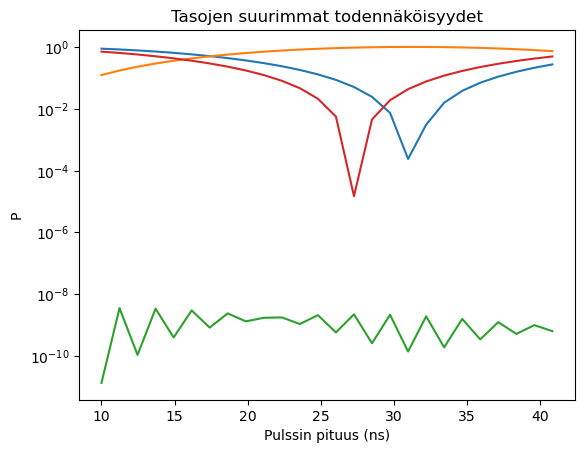

---------------------------------------------


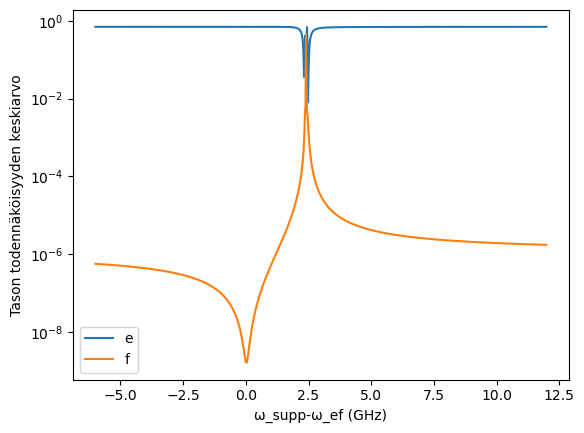

Amplitudi (GHz): 0.12744300694748215
AC-stark siirtymä (GHz): 0.02
E-tason suurin todennäköisyys: 0.9999608569204113
Pulssin pituus (ns): 27.258414959437925
Rabi-taajuus (fourier):  0.020364815423228766


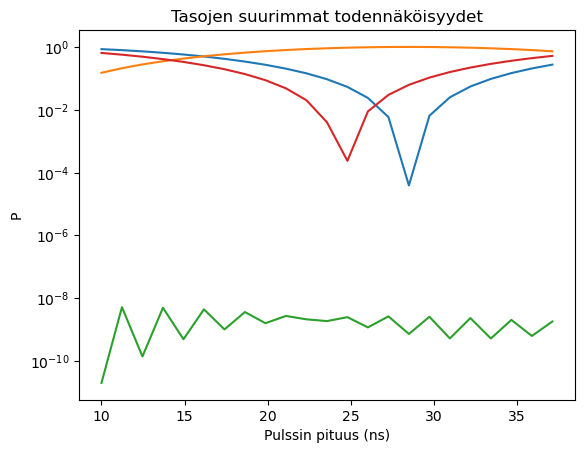

---------------------------------------------


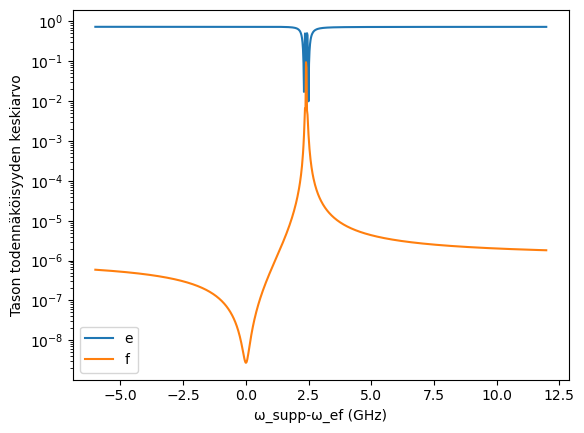

Amplitudi (GHz): 0.14018730764223034
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999921330722715
Pulssin pituus (ns): 26.02535559669603
Rabi-taajuus (fourier):  0.022327003165619697


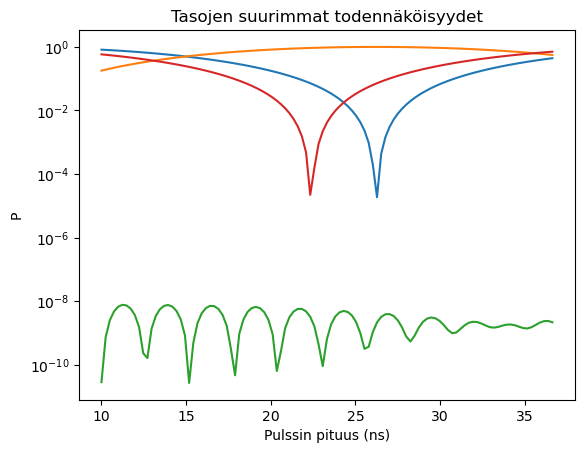

---------------------------------------------


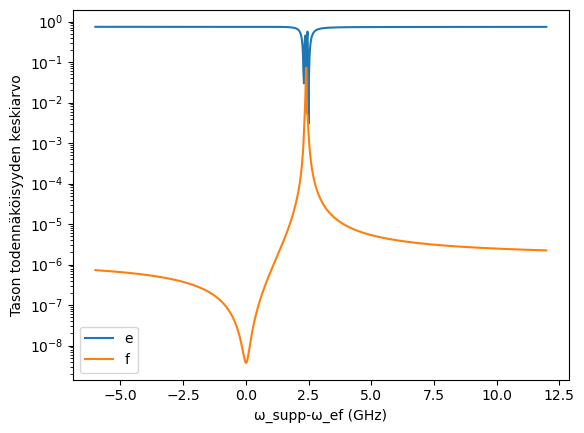

Amplitudi (GHz): 0.15293160833697855
AC-stark siirtymä (GHz): 0.0
E-tason suurin todennäköisyys: 0.9999947216770434
Pulssin pituus (ns): 24.79341058045875
Rabi-taajuus (fourier):  0.024359518611372533


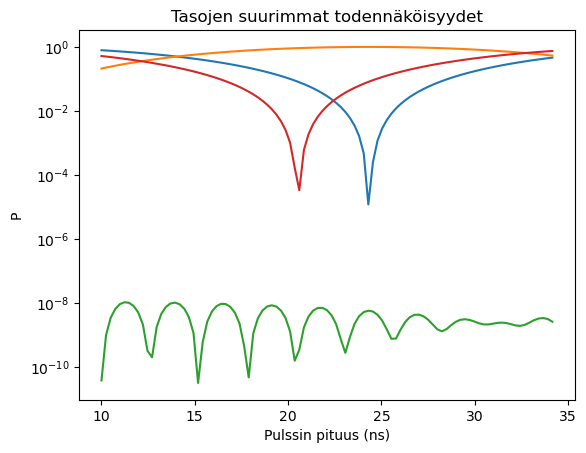

---------------------------------------------


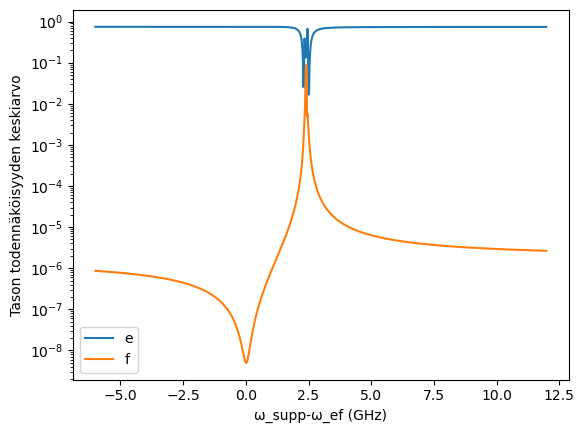

Amplitudi (GHz): 0.16567590903172677
AC-stark siirtymä (GHz): 0.02
E-tason suurin todennäköisyys: 0.999999549348307
Pulssin pituus (ns): 22.328176257602244
Rabi-taajuus (fourier):  0.02639316657594197


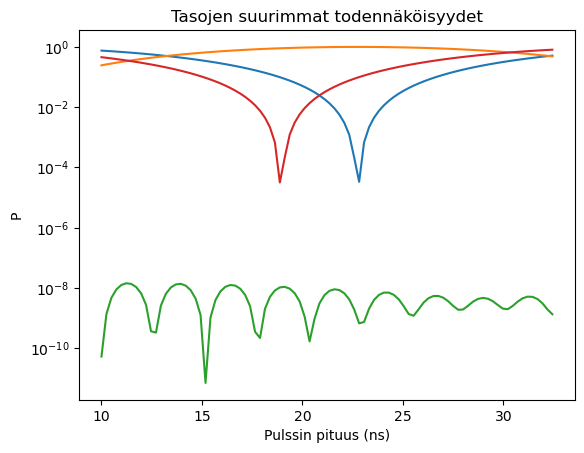

---------------------------------------------


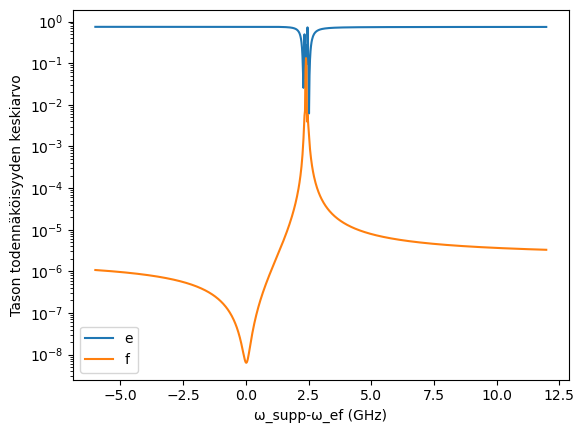

Amplitudi (GHz): 0.178420209726475
AC-stark siirtymä (GHz): 0.02
E-tason suurin todennäköisyys: 0.9999961614716192
Pulssin pituus (ns): 21.095792644202405
Rabi-taajuus (fourier):  0.028427041750142365


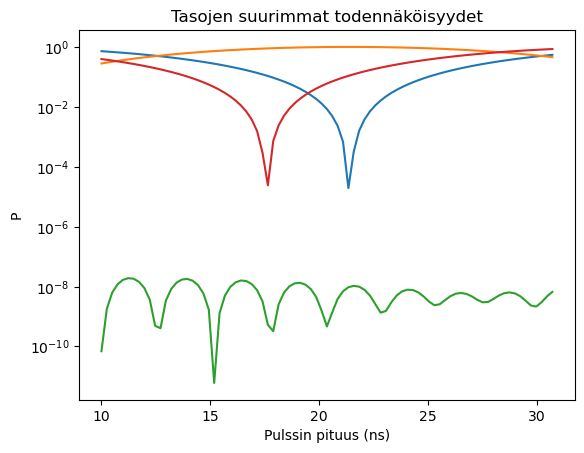

---------------------------------------------


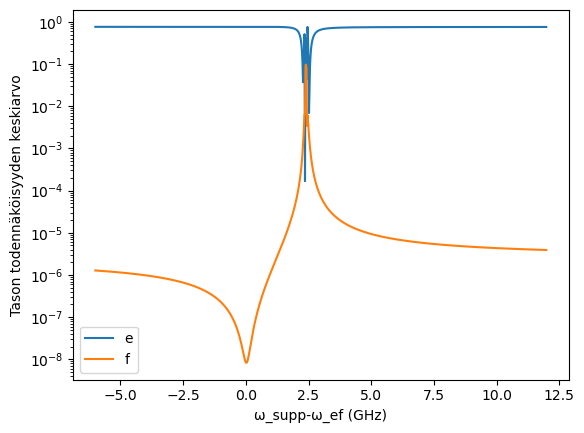

Amplitudi (GHz): 0.19116451042122318
AC-stark siirtymä (GHz): 0.02
E-tason suurin todennäköisyys: 0.9999977967404431
Pulssin pituus (ns): 19.86325305449639
Rabi-taajuus (fourier):  0.030453996027176612


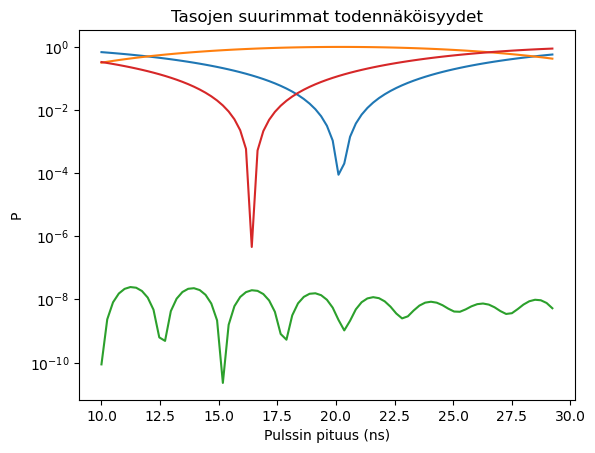

---------------------------------------------


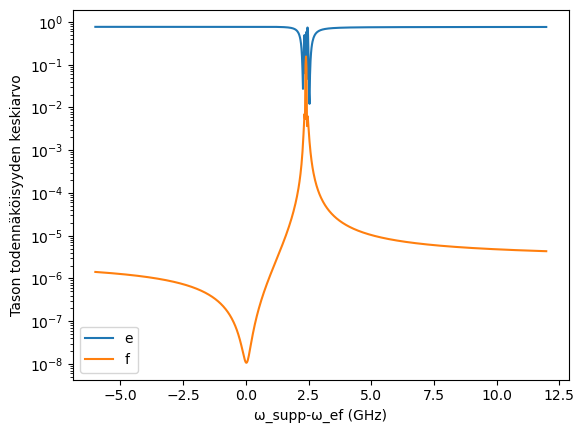

Amplitudi (GHz): 0.2039088111159714
AC-stark siirtymä (GHz): 0.02
E-tason suurin todennäköisyys: 0.9999967674469634
Pulssin pituus (ns): 18.630545930381295
Rabi-taajuus (fourier):  0.032486222081123305


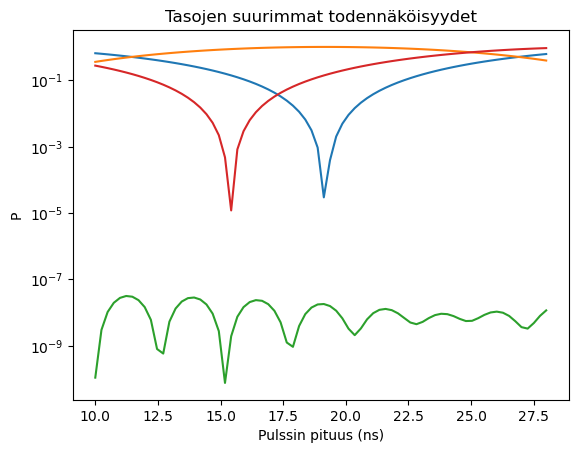

---------------------------------------------


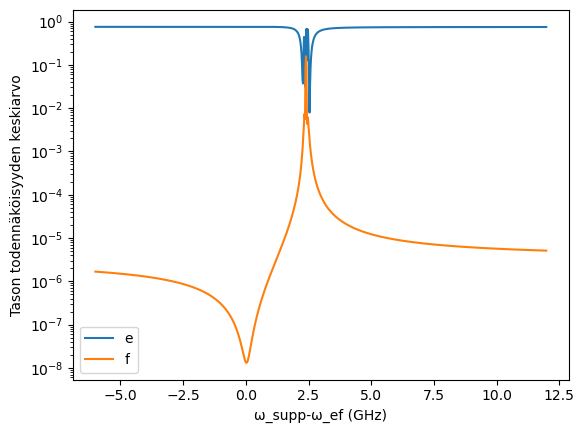

Amplitudi (GHz): 0.2166531118107196
AC-stark siirtymä (GHz): 0.02
E-tason suurin todennäköisyys: 0.9999912871983355
Pulssin pituus (ns): 18.630744137332684
Rabi-taajuus (fourier):  0.03451293836148751


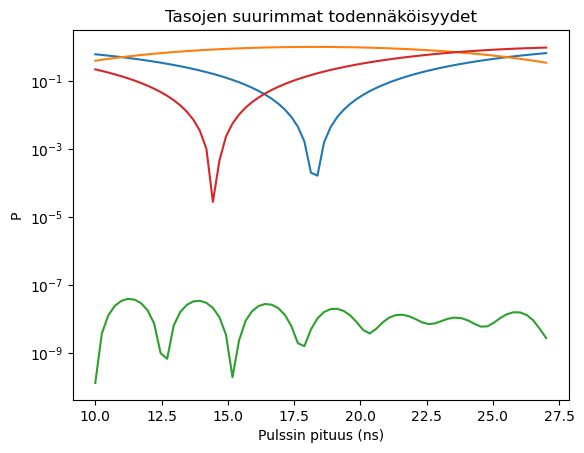

---------------------------------------------


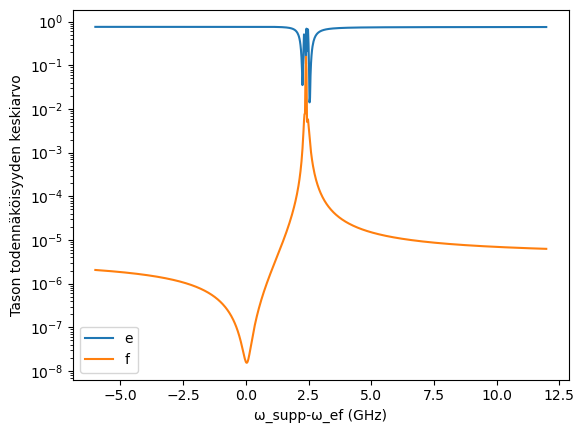

Amplitudi (GHz): 0.22939741250546783
AC-stark siirtymä (GHz): 0.04
E-tason suurin todennäköisyys: 0.9999858276979087
Pulssin pituus (ns): 17.398080125473594
Rabi-taajuus (fourier):  0.0365324875760208


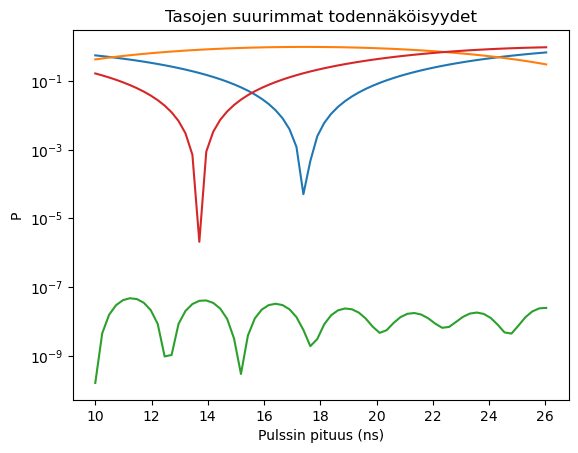

---------------------------------------------


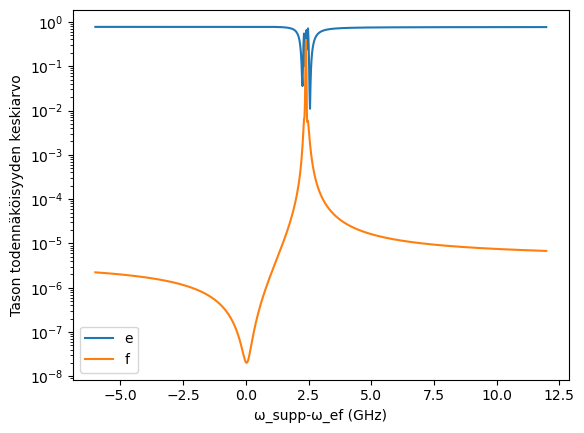

Amplitudi (GHz): 0.24214171320021607
AC-stark siirtymä (GHz): 0.04
E-tason suurin todennäköisyys: 0.9999952891211404
Pulssin pituus (ns): 16.165545281386198
Rabi-taajuus (fourier):  0.03855586119853503


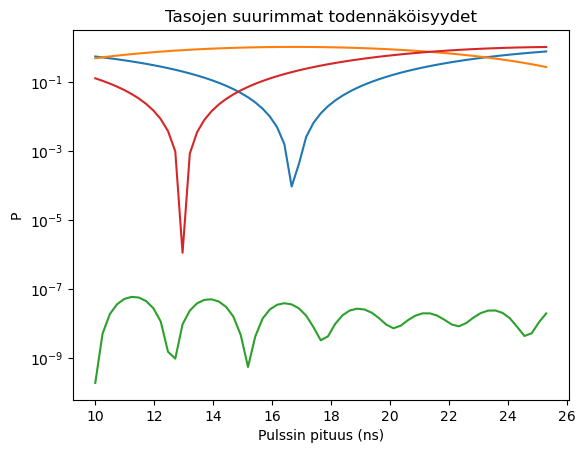

---------------------------------------------


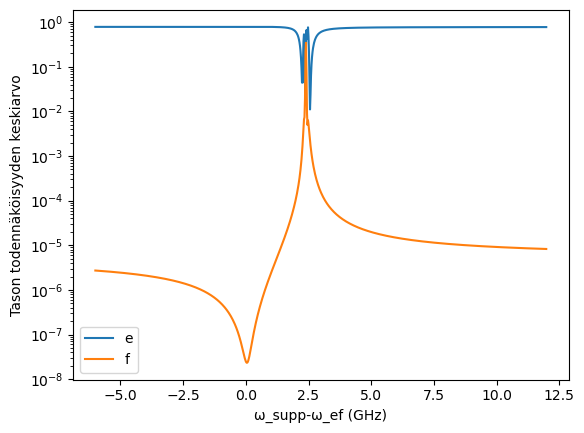

Amplitudi (GHz): 0.25488601389496424
AC-stark siirtymä (GHz): 0.04
E-tason suurin todennäköisyys: 0.999979194328112
Pulssin pituus (ns): 16.165473543814862
Rabi-taajuus (fourier):  0.040616079282615264


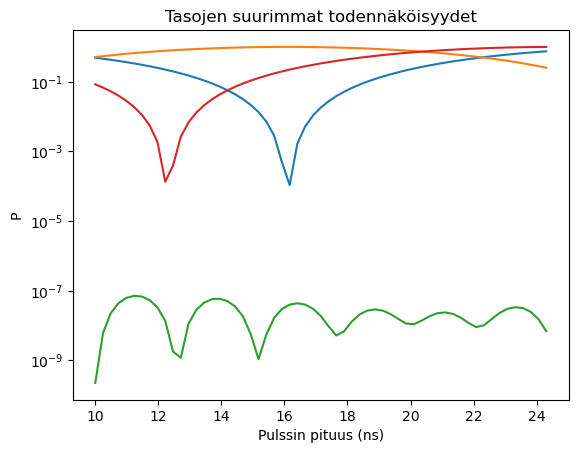

---------------------------------------------


In [7]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.0005
max_range = 0.0100
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_d_opt = qubit.frequency+list_AC_stark_vals[i] #Optimaalinen ajotaajuus

    f_rabi=5*A/3 #Arvaus Rabi-taajuudelle
    AC_stark=0 #Arvaus AC-stark siirtymälle
    
    params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi,AC_stark,[-300,600],50)

    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    m=10

    if A < 0.13:
        vals = pulses.sim_3_part_pulses(f_d_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,U_f=5,drag=True)
    else:
        vals = pulses.sim_3_part_pulses(f_d_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi)/m,t_ramp=5,U_f=1,drag=True)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])
    
    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
    plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
    plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
    plt.semilogy(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(0.012744300694748212), np.float64(0.025488601389496424), np.float64(0.03823290208424464), np.float64(0.05097720277899285), np.float64(0.06372150347374106), np.float64(0.07646580416848928), np.float64(0.08921010486323748), np.float64(0.1019544055579857), np.float64(0.11469870625273391), np.float64(0.12744300694748215), np.float64(0.14018730764223034), np.float64(0.15293160833697855), np.float64(0.16567590903172677), np.float64(0.178420209726475), np.float64(0.19116451042122318), np.float64(0.2039088111159714), np.float64(0.2166531118107196), np.float64(0.22939741250546783), np.float64(0.24214171320021607), np.float64(0.25488601389496424)]


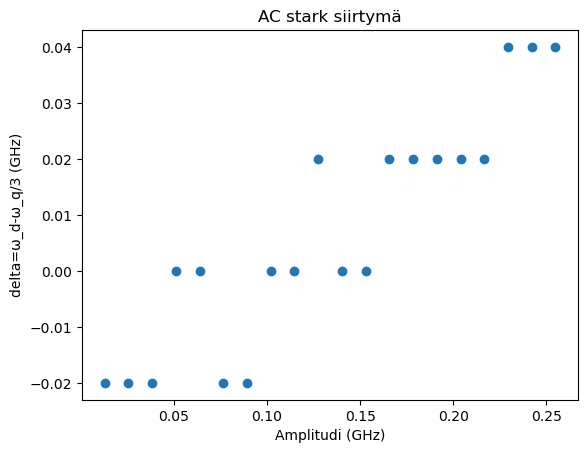

[-0.02, -0.02, -0.02, 0.0, 0.0, -0.02, -0.02, 0.0, 0.0, 0.02, 0.0, 0.0, 0.02, 0.02, 0.02, 0.02, 0.02, 0.04, 0.04, 0.04]


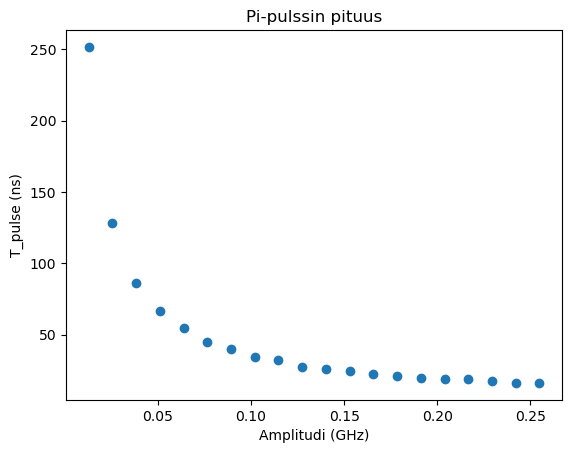

[np.float64(251.57913925969248), np.float64(128.32398047912534), np.float64(86.42008713843916), np.float64(66.69827479772013), np.float64(54.37380171001159), np.float64(44.51247984782758), np.float64(39.58287287057783), np.float64(34.65298406944798), np.float64(32.18810885817389), np.float64(27.258414959437925), np.float64(26.02535559669603), np.float64(24.79341058045875), np.float64(22.328176257602244), np.float64(21.095792644202405), np.float64(19.86325305449639), np.float64(18.630545930381295), np.float64(18.630744137332684), np.float64(17.398080125473594), np.float64(16.165545281386198), np.float64(16.165473543814862)]


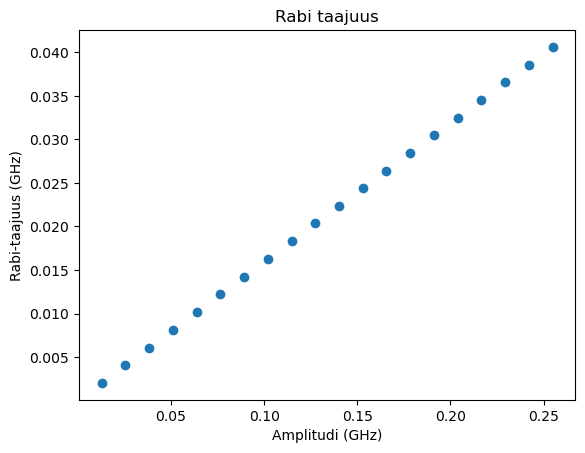

[np.float64(0.0020283208289489786), np.float64(0.0040566586591860125), np.float64(0.006092403122079832), np.float64(0.008126666079726248), np.float64(0.010162290356581387), np.float64(0.012200010936201995), np.float64(0.014232986546675541), np.float64(0.01627948127948988), np.float64(0.01829876715448028), np.float64(0.020364815423228766), np.float64(0.022327003165619697), np.float64(0.024359518611372533), np.float64(0.02639316657594197), np.float64(0.028427041750142365), np.float64(0.030453996027176612), np.float64(0.032486222081123305), np.float64(0.03451293836148751), np.float64(0.0365324875760208), np.float64(0.03855586119853503), np.float64(0.040616079282615264)]


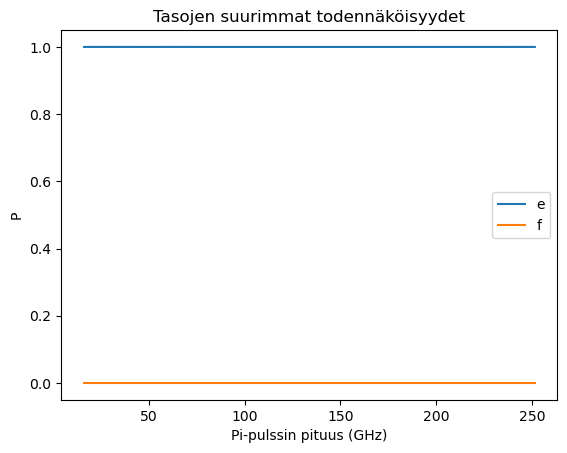

[np.float64(0.9999754574461227), np.float64(0.9998881960536458), np.float64(0.9998836561651651), np.float64(0.9999934650452958), np.float64(0.9999662126031618), np.float64(0.9999750422841611), np.float64(0.9999940639264325), np.float64(0.9999996829282374), np.float64(0.9999972875014858), np.float64(0.9999608569204113), np.float64(0.9999921330722715), np.float64(0.9999947216770434), np.float64(0.999999549348307), np.float64(0.9999961614716192), np.float64(0.9999977967404431), np.float64(0.9999967674469634), np.float64(0.9999912871983355), np.float64(0.9999858276979087), np.float64(0.9999952891211404), np.float64(0.999979194328112)]
[np.float64(3.3702707655190157e-12), np.float64(2.1383776675802305e-11), np.float64(7.374942499189344e-11), np.float64(1.8907903828502104e-10), np.float64(4.045834896183782e-10), np.float64(8.036086696855709e-10), np.float64(1.4248031673766024e-09), np.float64(2.2715903874682035e-09), np.float64(3.5260545457355142e-09), np.float64(5.278919957296314e-09), np.f

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)